# Notebook 11 – EDA Visualization
Dataset: `telecom_customer_churn.csv`

**Exploratory Data Analysis (EDA)** visualization uses charts and graphs to uncover patterns, spot anomalies, and test assumptions in raw data before building models.

For every plot we cover: **why it was selected**, the **visualization itself**, its **interpretation**, and the **insight** it produces.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
df = pd.read_csv("telecom_customer_churn.csv")
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-10681,Male,0,Yes,No,24.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,80.04,1900.19,No
1,CUST-10024,Female,0,Yes,No,35.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,42.99,1539.83,No
2,CUST-10621,Male,0,Yes,No,68.0,Yes,DSL,Month-to-month,Yes,Electronic check,79.31,5401.35,Yes
3,CUST-10099,Male,0,Yes,Yes,18.0,Yes,Fiber optic,Month-to-month,Yes,Electronic check,113.02,2022.80,No
4,CUST-10284,Male,1,Yes,Yes,34.0,Yes,No,Month-to-month,No,Electronic check,28.78,966.99,Yes


## 1. Histogram – Distribution of Tenure
**Why selected:** `tenure_months` is a continuous numeric variable. A histogram is the natural first choice to see how customer tenure is spread across the range, and whether it clusters at any particular values.

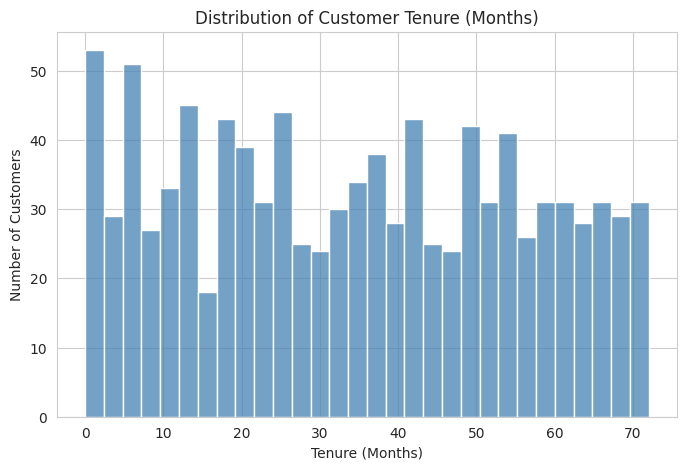

In [2]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="tenure_months", bins=30, color="steelblue", kde=False)
plt.title("Distribution of Customer Tenure (Months)")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

**Interpretation:** The distribution is fairly spread out across 0–72 months rather than following a smooth bell curve, with noticeably higher bars at the very low end (new customers) and the very high end (long-tenured customers).

**Insight:** The company has a large base of brand-new customers as well as a loyal long-term base, but comparatively fewer customers in the middle tenure range. This bimodal-like pattern suggests two distinct customer lifecycles: those who churn early and those who stay for the long run.

## 2. Distribution Plot – Total Charges (with KDE)
**Why selected:** `total_charges` spans a wide range and is likely skewed since it accumulates over tenure. A distribution plot (histogram + KDE curve) shows both the shape and the skewness clearly, which a plain histogram alone communicates less smoothly.

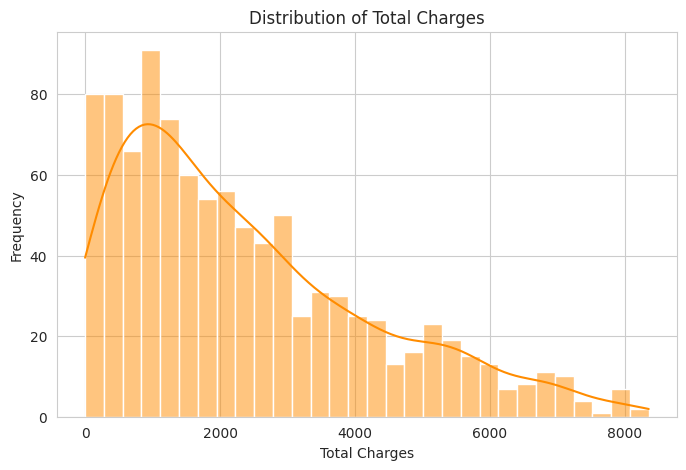

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="total_charges", bins=30, kde=True, color="darkorange")
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** The KDE curve shows a right-skewed distribution, with a large concentration of customers at lower total charges and a long tail extending toward higher values.

**Insight:** Most customers have accumulated relatively low total charges, which aligns with the earlier observation of many short-tenure customers. The long right tail represents a smaller group of high-value, long-term customers who contribute disproportionately to revenue.

## 3. Box Plot – Monthly Charges by Churn
**Why selected:** A box plot is ideal for comparing the spread, median, and outliers of a continuous variable (`monthly_charges`) across the two categories of the target variable (`churn`).

/tmp/ipykernel_485/3153675345.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="churn", y="monthly_charges", palette="Set2")


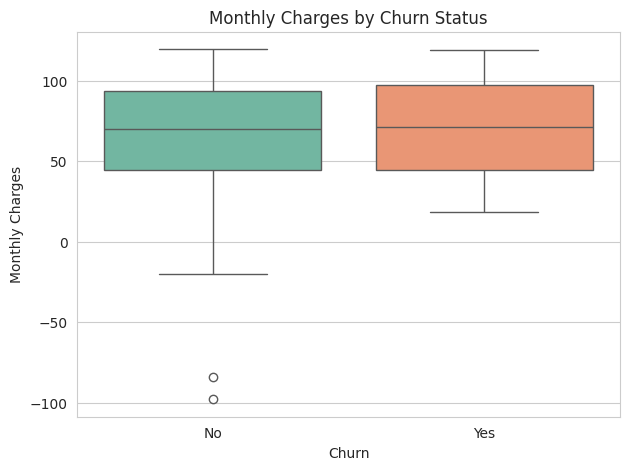

In [4]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="churn", y="monthly_charges", palette="Set2")
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

**Interpretation:** Customers who churned have a slightly higher median monthly charge than those who stayed, and their interquartile range is shifted upward. A few low outliers exist, including negative values that are likely data entry errors.

**Insight:** Higher monthly charges are mildly associated with churn, suggesting that price sensitivity could be a contributing factor. The negative values flagged here should be investigated and cleaned before modeling.

## 4. Violin Plot – Tenure by Churn
**Why selected:** A violin plot combines a box plot with a density estimate, which is useful here to compare not just the central tendency but the full shape of the tenure distribution between churned and retained customers.

/tmp/ipykernel_485/2145996565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="churn", y="tenure_months", palette="Set3")


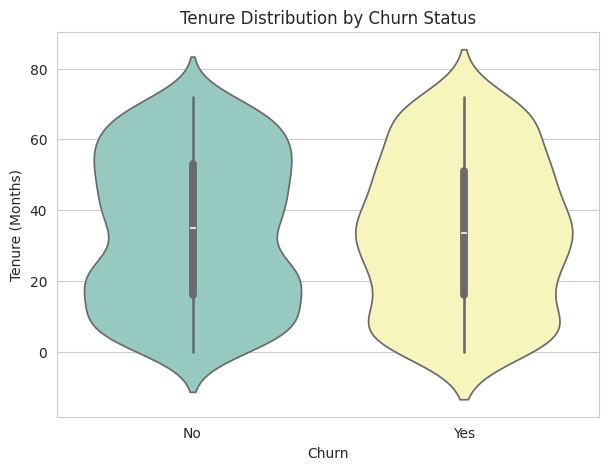

In [5]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x="churn", y="tenure_months", palette="Set3")
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

**Interpretation:** The violin for churned customers is wider near the low tenure values, indicating a higher density of early-tenure customers among those who churned. The retained group shows a more even spread across the tenure range.

**Insight:** Customers are most vulnerable to churning early in their relationship with the company. Retention efforts targeted at the first few months could meaningfully reduce churn.

## 5. Bar Chart – Churn Rate by Contract Type
**Why selected:** `contract` is categorical, and the business question is how churn *rate* (not raw counts) differs across contract types. A bar chart of the aggregated churn rate per category directly answers this, which a simple count plot cannot show.

/tmp/ipykernel_485/3391147304.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate_by_contract.index, y=churn_rate_by_contract.values, palette="Reds_r")


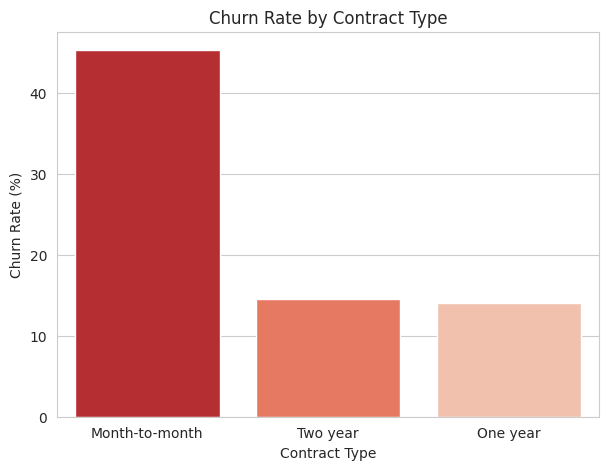

In [6]:
churn_rate_by_contract = df.groupby("contract")["churn"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=churn_rate_by_contract.index, y=churn_rate_by_contract.values, palette="Reds_r")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

**Interpretation:** Month-to-month contracts show a churn rate far higher than one-year or two-year contracts, which are close to each other and much lower.

**Insight:** Contract length is one of the strongest churn drivers in this dataset. Encouraging customers to move from month-to-month to longer commitments could substantially reduce churn.

## 6. Count Plot – Internet Service Type
**Why selected:** `internet_service` is categorical with a small number of levels. A count plot is the direct way to see how customers are distributed across service types before analyzing its relationship with churn.

/tmp/ipykernel_485/2304408168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="internet_service", order=df["internet_service"].value_counts().index, palette="Blues_d")


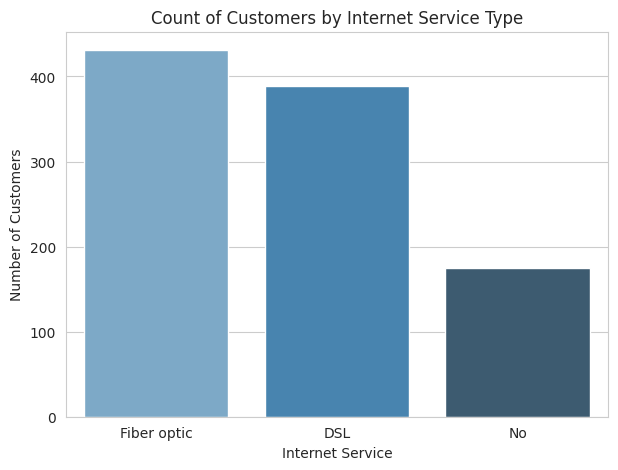

In [7]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="internet_service", order=df["internet_service"].value_counts().index, palette="Blues_d")
plt.title("Count of Customers by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

**Interpretation:** Fiber optic and DSL are the two dominant service types with fairly close counts, while a smaller group of customers has no internet service at all.

**Insight:** Fiber optic is the most common service, which is relevant because (as later analysis often shows in telecom data) fiber customers frequently pay more and may churn at different rates than DSL customers — worth cross-checking with churn in further analysis.

## 7. Scatter Plot – Monthly Charges vs Total Charges
**Why selected:** Both variables are continuous, and a scatter plot is the standard way to examine the relationship between two numeric variables. Coloring by `churn` adds a third dimension to see if the relationship differs by class.

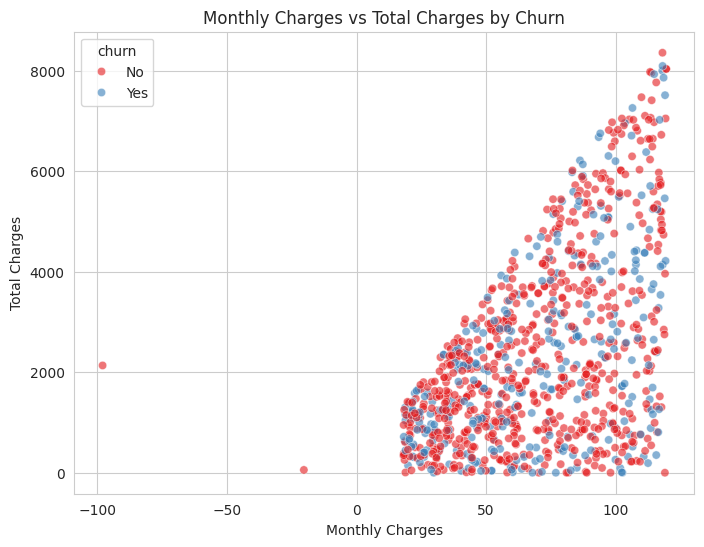

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="monthly_charges", y="total_charges", hue="churn", alpha=0.6, palette="Set1")
plt.title("Monthly Charges vs Total Charges by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.show()

**Interpretation:** There is a clear positive relationship between monthly and total charges, as expected since total charges accumulate from monthly billing. Churned customers (orange) are concentrated more toward the lower total-charges region even at varying monthly charge levels.

**Insight:** Because total charges are driven heavily by tenure, churned customers clustering at low total charges reinforces the earlier finding that churn happens disproportionately among newer customers, rather than being driven by monthly price alone.

## 8. Line Plot – Average Monthly Charges Across Tenure
**Why selected:** A line plot is appropriate for showing a trend across an ordered variable. Binning tenure and plotting the average monthly charge per bin reveals whether pricing patterns shift as customers stay longer.

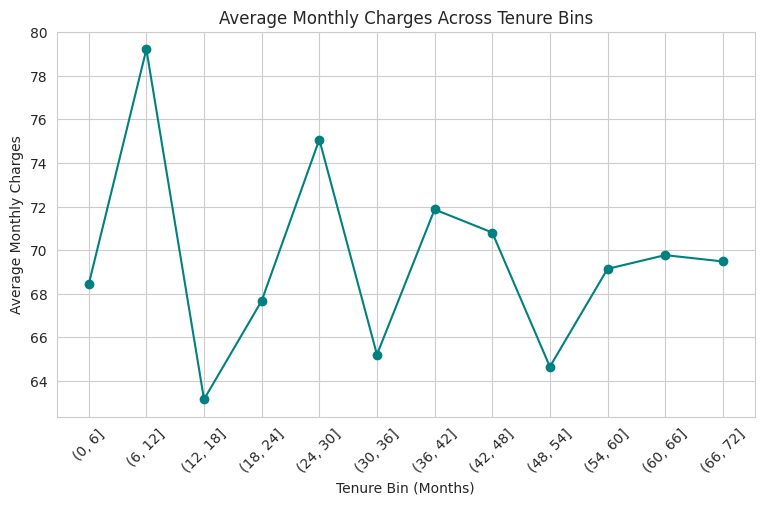

In [9]:
df_tenure = df.dropna(subset=["tenure_months"]).copy()
df_tenure["tenure_bin"] = pd.cut(df_tenure["tenure_months"], bins=range(0, 78, 6))
avg_charges_by_tenure = df_tenure.groupby("tenure_bin", observed=True)["monthly_charges"].mean()

plt.figure(figsize=(9, 5))
plt.plot(avg_charges_by_tenure.index.astype(str), avg_charges_by_tenure.values, marker="o", color="teal")
plt.title("Average Monthly Charges Across Tenure Bins")
plt.xlabel("Tenure Bin (Months)")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=45)
plt.show()

**Interpretation:** Average monthly charges stay relatively flat across most tenure bins, without a strong upward or downward trend, though minor fluctuations appear at the extreme bins.

**Insight:** Pricing does not appear to systematically increase or decrease with how long a customer has stayed, suggesting monthly charges are driven more by the specific service plan a customer selects than by their tenure.

## 9. Heatmap – Correlation Matrix of Numeric Features
**Why selected:** With multiple numeric columns (`tenure_months`, `monthly_charges`, `total_charges`, `senior_citizen`), a heatmap of the correlation matrix is the most efficient way to detect linear relationships and potential multicollinearity at a glance.

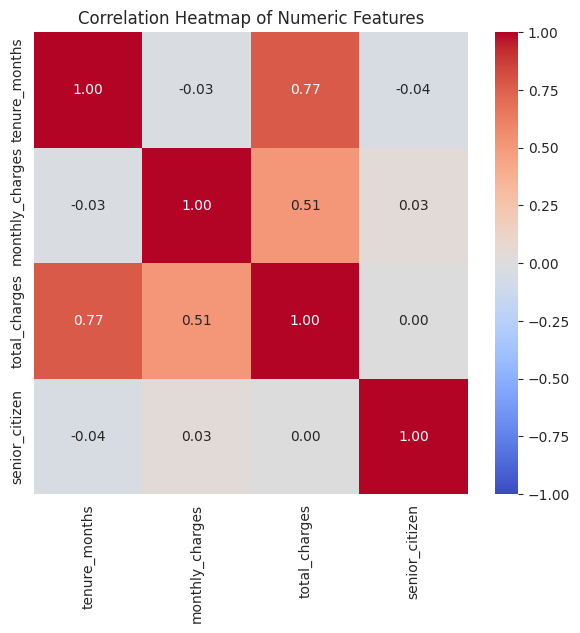

In [10]:
numeric_cols = ["tenure_months", "monthly_charges", "total_charges", "senior_citizen"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

**Interpretation:** `total_charges` is strongly correlated with `tenure_months` (about 0.77) and moderately correlated with `monthly_charges` (about 0.51), which makes sense since total charges accumulate as a function of both. `senior_citizen` shows negligible correlation with the other numeric features.

**Insight:** `total_charges` is largely a derived/redundant variable relative to tenure and monthly charges. In a modeling context, this multicollinearity should be handled — for example, by dropping `total_charges` or using regularization — to avoid inflating the importance of correlated features.

## 10. Pair Plot – Numeric Features by Churn
**Why selected:** A pair plot gives a compact multivariate view of all pairwise relationships between the key numeric features in one figure, with churn as the hue. This ties together the individual scatter and distribution observations made above into a single comparative view.

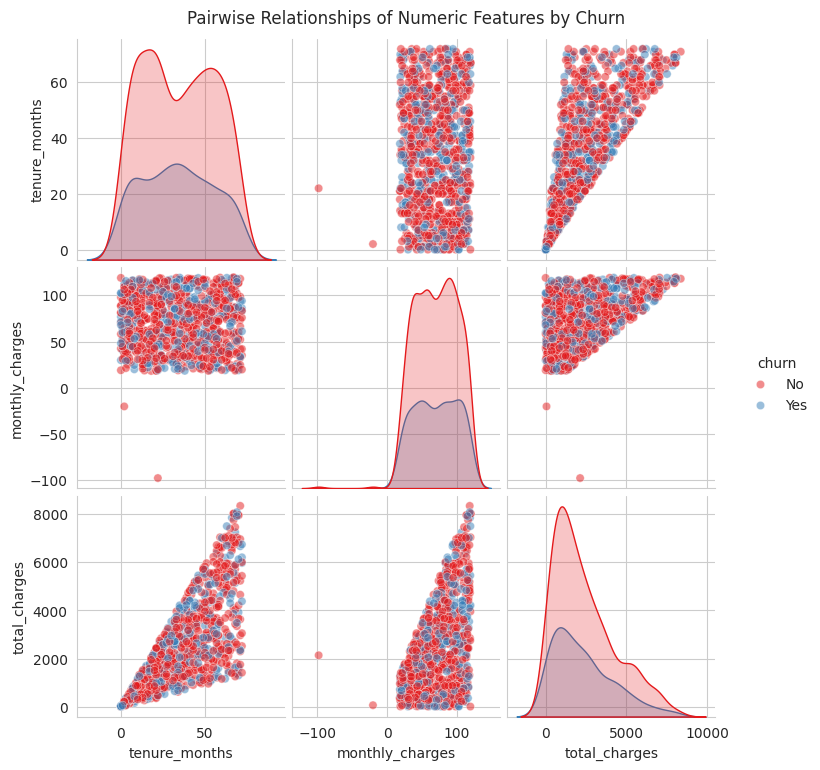

In [11]:
pairplot_cols = ["tenure_months", "monthly_charges", "total_charges", "churn"]
sns.pairplot(df.dropna(subset=pairplot_cols)[pairplot_cols], hue="churn", palette="Set1", diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairwise Relationships of Numeric Features by Churn", y=1.02)
plt.show()

**Interpretation:** The diagonal KDE plots confirm that churned customers skew toward lower tenure, while the off-diagonal scatter plots confirm the strong tenure–total_charges relationship and show churned customers concentrated in the low-tenure, low-total-charges region across almost every pairing.

**Insight:** Tenure is the most consistently discriminating numeric feature for churn across all pairwise views, reinforcing that early-tenure customers are the primary churn risk group and should be the focus of any predictive model or retention strategy.